#PREDIKSI HARGA RUMAH YOGYAKARTA - LINEAR REGRESSION, DECISION TREE, AND RANDOM FOREST

##1. Import library yang dibutuhkan

In [4]:
# ============================================
# 1. Import Library
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Untuk visualisasi lokasi (jika tidak ada koordinat, kita gunakan bar chart)
import plotly.express as px  # optional, tapi lebih bagus
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

##2. Load Dataset dan Data Understanding


In [5]:
# ============================================
# 2. Load Data
# ============================================
df = pd.read_csv("rumah_jogja_new.csv")
print("Jumlah data awal:", len(df))
print("\n5 data pertama:")
print(df.head())
print("\nInformasi dataset:")
print(df.info())

Jumlah data awal: 2000

5 data pertama:
       district        city  landSize  buildingSize  bedrooms  bathrooms  \
0       Ngaglik      Sleman      96.0         100.0       3.0        2.0   
1       Ngaglik      Sleman     262.0         155.0       3.0        2.0   
2         Depok      Sleman     177.0          85.0       3.0        2.0   
3       Ngaglik      Sleman     710.0         200.0       5.0        3.0   
4  Gondokusuman  Yogyakarta     136.0         136.0       5.0        2.0   

   floors  garages electricity   furnishing  priceNumeric  
0     2.0      NaN     Lainnya  Unfurnished     950000000  
1     1.0      NaN   1300 Watt  Unfurnished    1200000000  
2     1.0      1.0   1300 Watt  Unfurnished    1200000000  
3     1.0      2.0     Lainnya  Unfurnished    2400000000  
4     1.0      NaN   2200 Watt  Unfurnished     800000000  

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column     

Dataset awal: 2000 data dengan 11 kolom (district, city, landSize, buildingSize, bedrooms, bathrooms, floors, garages, electricity, furnishing, priceNumeric).

Kita perlu memahami tipe data dari setiap kolom untuk menentukan metode preprocessing yang sesuai. Tipe data numerik akan memerlukan normalisasi, sedangkan tipe data kategorikal memerlukan encoding.

##3. Exploratory Data Analysis (EDA)

In [6]:
print("\nMissing values per kolom:")
print(df.isnull().sum())


Missing values per kolom:
district          55
city              55
landSize          15
buildingSize      15
bedrooms          40
bathrooms         43
floors           104
garages         1367
electricity       20
furnishing       262
priceNumeric       0
dtype: int64


Berdasarkan hasil pengecekan, missing values cukup banyak terutama pada kolom garages (1367 missing), furnishing (262), dan floors (104).

### Visualisasi Distribusi Harga Rumah

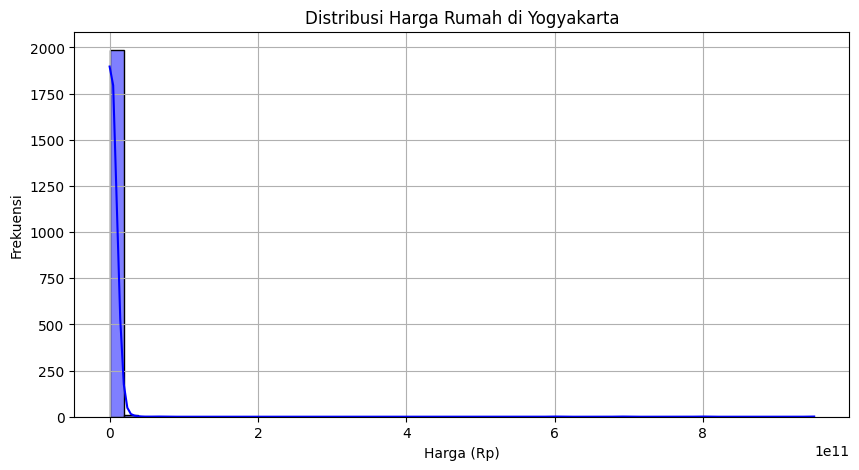

In [7]:
# Distribusi Harga Rumah
plt.figure(figsize=(10,5))
sns.histplot(df['priceNumeric'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribusi Harga Rumah di Yogyakarta')
plt.xlabel('Harga (Rp)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

###Hubungan antara Luas Tanah dan Harga

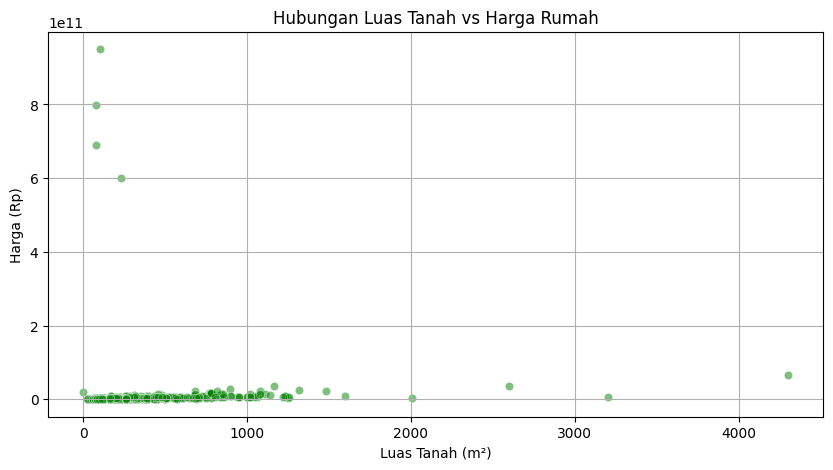

In [8]:
# Hubungan antara Luas Tanah (landSize) dan Harga
plt.figure(figsize=(10,5))
sns.scatterplot(x='landSize', y='priceNumeric', data=df, alpha=0.5, color='green')
plt.title('Hubungan Luas Tanah vs Harga Rumah')
plt.xlabel('Luas Tanah (m²)')
plt.ylabel('Harga (Rp)')
plt.grid(True)
plt.show()

###Visualisasi Lokasi berdasarkan Kecamatan

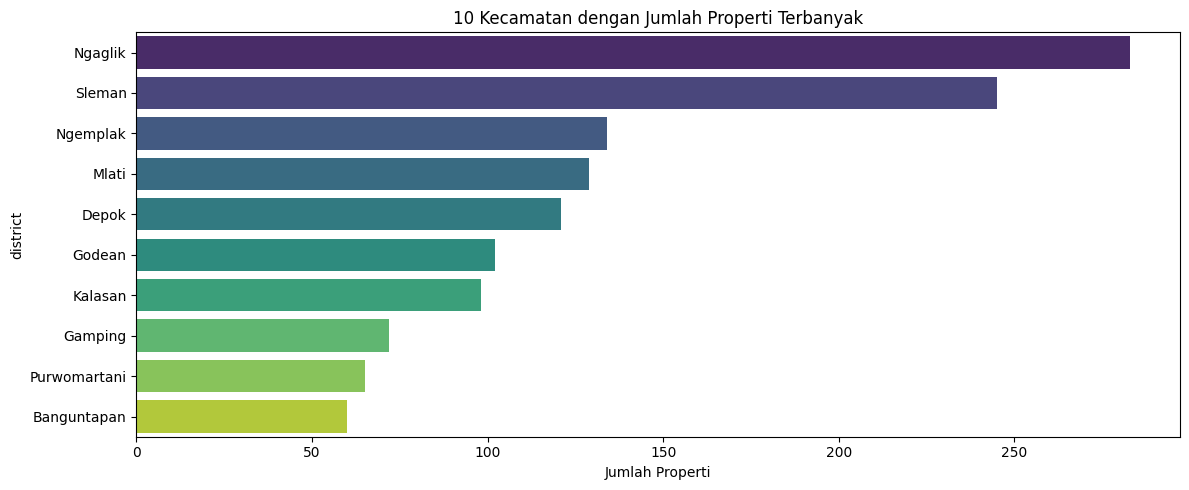

In [9]:
# Visualisasi Lokasi (berdasarkan district/kota)
# Jika tidak ada koordinat, kita gunakan count plot
plt.figure(figsize=(12,5))
top_districts = df['district'].value_counts().head(10)
sns.barplot(x=top_districts.values, y=top_districts.index, palette='viridis')
plt.title('10 Kecamatan dengan Jumlah Properti Terbanyak')
plt.xlabel('Jumlah Properti')
plt.tight_layout()
plt.show()

###Visualisasi Rata-rata Harga per Kecamatan

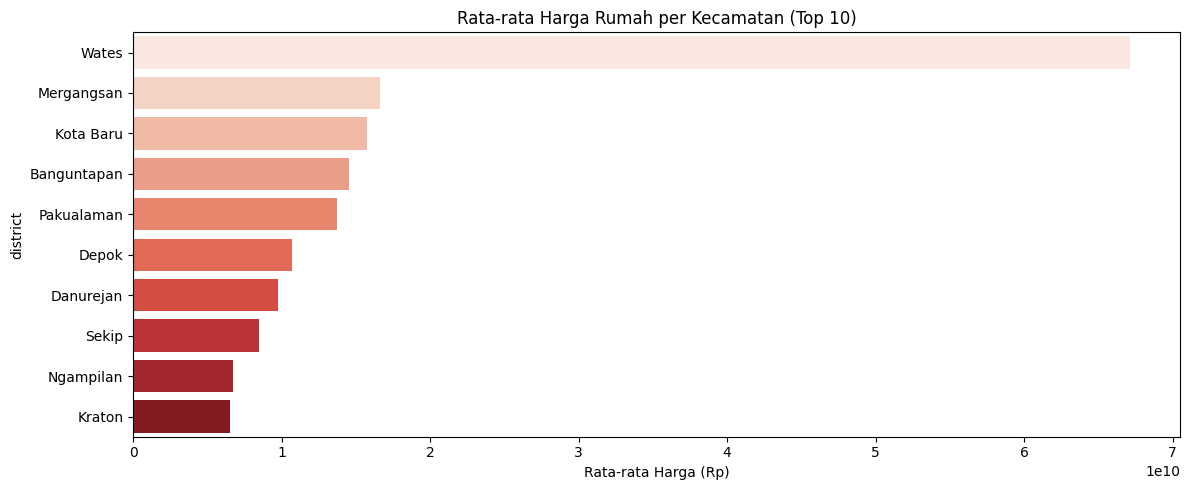

In [10]:
# Rata-rata harga per district (top 10)
avg_price_district = df.groupby('district')['priceNumeric'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=avg_price_district.values, y=avg_price_district.index, palette='Reds')
plt.title('Rata-rata Harga Rumah per Kecamatan (Top 10)')
plt.xlabel('Rata-rata Harga (Rp)')
plt.tight_layout()
plt.show()

###Matriks Korelasi

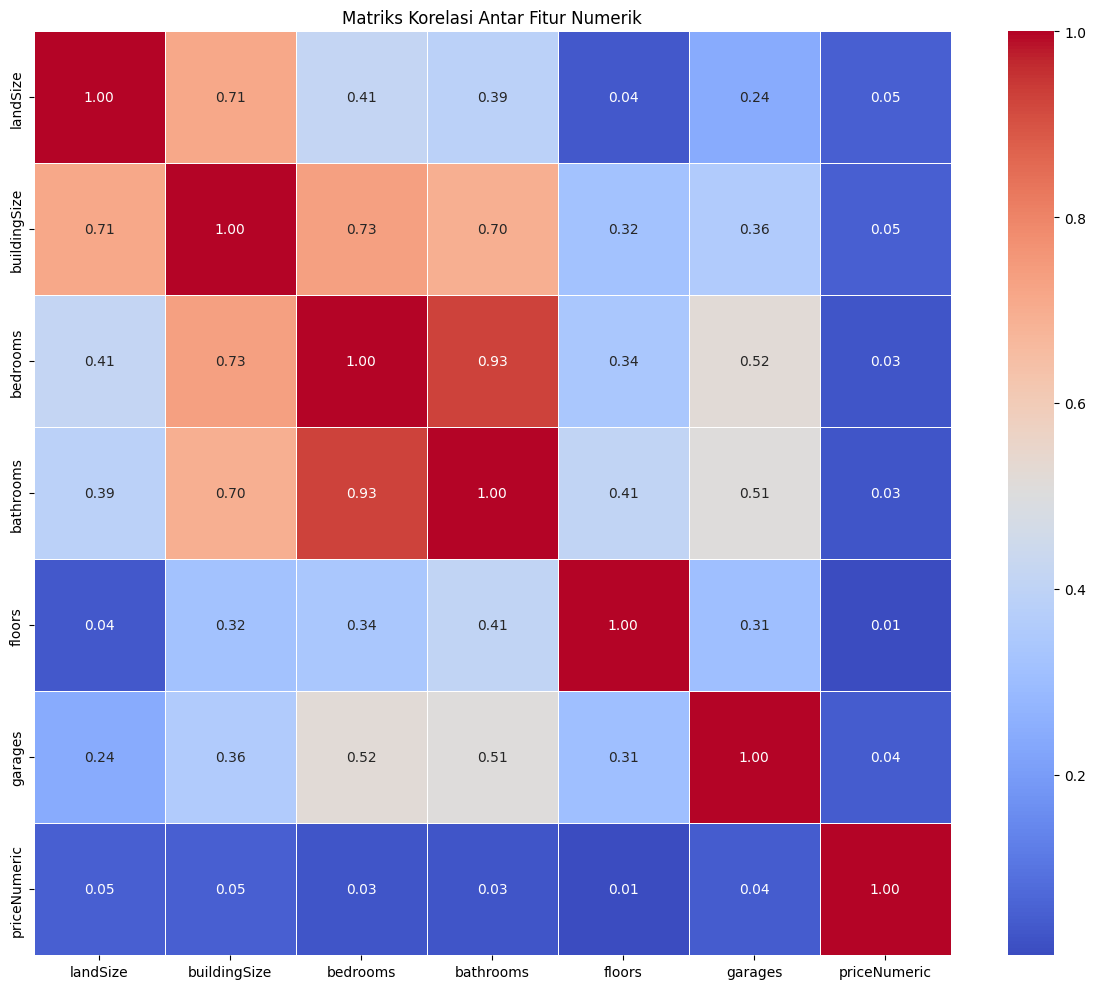


Korelasi fitur numerik dengan harga:
priceNumeric    1.000000
landSize        0.051945
buildingSize    0.051025
garages         0.042599
bathrooms       0.027664
bedrooms        0.025503
floors          0.005418
Name: priceNumeric, dtype: float64


In [11]:
# Matriks Korelasi (hanya kolom numerik)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Hapus kolom yang tidak relevan
if 'id' in numeric_cols:
    numeric_cols.remove('id')
if 'priceNumeric' in numeric_cols:
    numeric_cols.remove('priceNumeric')
# Korelasi dengan harga
corr_matrix = df[numeric_cols + ['priceNumeric']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

# Tampilkan korelasi dengan priceNumeric
corr_with_price = corr_matrix['priceNumeric'].sort_values(ascending=False)
print("\nKorelasi fitur numerik dengan harga:")
print(corr_with_price)

Hasil:

* landSize (0.052) dan buildingSize (0.051) memiliki korelasi tertinggi, namun masih sangat lemah.

* Ini mengindikasikan bahwa harga rumah dipengaruhi banyak faktor kategorikal (seperti lokasi) yang belum terlihat dari korelasi numerik sederhana.



##4. Cleaning Data

In [12]:
# ============================================
# 4. Pembersihan Data
# ============================================
# 4a. Hapus baris tanpa harga
df = df.dropna(subset=['priceNumeric'])

Menghapus semua baris kecuali harga

In [13]:
# 4b. Filter outlier harga (IQR)
Q1 = df['priceNumeric'].quantile(0.25)
Q3 = df['priceNumeric'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['priceNumeric'] >= lower) & (df['priceNumeric'] <= upper)]
print(f"Setelah filter IQR: {len(df)} data")

Setelah filter IQR: 1848 data


Memfilter data dari 2000 data menjadi 1848 data

In [14]:
# 4c. Imputasi kolom numerik dengan median
num_cols = ['landSize', 'buildingSize', 'bedrooms', 'bathrooms', 'floors']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [15]:
# 4d. Garages -> isi 0 (anggap tidak ada garasi)
df['garages'] = df['garages'].fillna(0)

In [16]:
# 4e. Furnishing -> 'Unknown'
df['furnishing'] = df['furnishing'].fillna('Unknown')

In [17]:
# 4f. Electricity: ekstrak angka, median untuk missing
df['electricity'] = df['electricity'].astype(str).str.extract(r'(\d+)')[0]
df['electricity'] = pd.to_numeric(df['electricity'], errors='coerce')
df['electricity'].fillna(df['electricity'].median(), inplace=True)

In [18]:
# 4g. District & city: isi 'Unknown'
df['district'] = df['district'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')

In [19]:
# 4h. Drop baris yang masih NaN (seharusnya sudah tidak ada)
df = df.dropna()
print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 1848


Final data: 1848 sampel dengan 12 fitur

In [20]:
import json

# Buat mapping city -> list of unique districts
city_district_map = df.groupby('city')['district'].unique().apply(list).to_dict()

# Simpan ke file JSON
with open('city_district_mapping.json', 'w') as f:
    json.dump(city_district_map, f, indent=2)

print("Mapping kota -> kecamatan disimpan ke city_district_mapping.json")

Mapping kota -> kecamatan disimpan ke city_district_mapping.json


##5. Feature Engineering

In [21]:
# ============================================
# 5. Feature Engineering
# ============================================
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['land_building_ratio'] = df['landSize'] / (df['buildingSize'] + 1e-6) # hindari division by zero

##6. Encoding Kategorikal

In [22]:
# ============================================
# 6. Encoding Kategorikal (LabelEncoder untuk setiap kolom kategorikal)
# ============================================
le_district = LabelEncoder()
le_city = LabelEncoder()
le_furnishing = LabelEncoder()

df['district_enc'] = le_district.fit_transform(df['district'])
df['city_enc'] = le_city.fit_transform(df['city'])
df['furnishing_enc'] = le_furnishing.fit_transform(df['furnishing'])

# Fitur yang digunakan
features = [
    'landSize', 'buildingSize', 'bedrooms', 'bathrooms', 'floors', 'garages',
    'electricity', 'total_rooms', 'land_building_ratio',
    'district_enc', 'city_enc', 'furnishing_enc'
]

X = df[features]
y = df['priceNumeric']

print("\nFitur setelah encoding:")
print(X.head())


Fitur setelah encoding:
   landSize  buildingSize  bedrooms  bathrooms  floors  garages  electricity  \
0      96.0         100.0       3.0        2.0     2.0      0.0       2200.0   
1     262.0         155.0       3.0        2.0     1.0      0.0       1300.0   
2     177.0          85.0       3.0        2.0     1.0      1.0       1300.0   
3     710.0         200.0       5.0        3.0     1.0      2.0       2200.0   
4     136.0         136.0       5.0        2.0     1.0      0.0       2200.0   

   total_rooms  land_building_ratio  district_enc  city_enc  furnishing_enc  
0          5.0             0.960000            29         3               2  
1          5.0             1.690323            29         3               2  
2          5.0             2.082353             8         3               2  
3          8.0             3.550000            29         3               2  
4          7.0             1.000000            13         5               2  


Menggunakan LabelEncoder untuk kolom district, city, furnishing.
Alasan: Random Forest dan Decision Tree dapat menangani label encoding dengan baik (tidak memerlukan one‑hot encoding yang memperbesar dimensi).

##7. Split Data 80% training, 20% testing

In [23]:
# ============================================
# 7. Split Data (80% training, 20% testing)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} data, Test: {len(X_test)} data")

Train: 1478 data, Test: 370 data


train_test_split dengan test_size=0.2 dan random_state=42.
Tujuan: memisahkan 80% data untuk latih, 20% untuk uji. random_state memastikan hasil konsisten.

##8. Scaling Linear Regression

In [24]:
# ============================================
# 8. Scaling (penting untuk Linear Regression)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Menggunakan StandardScaler → mengubah fitur numerik menjadi mean = 0, std = 1.
Alasan: Linear Regression sensitif terhadap skala fitur; scaling membantu koefisien menjadi sebanding.

## 9. Model Development

###9.1 Model 1: Linear Regression

In [25]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

###9.2 Model 2: Decision Tree Regressor

In [26]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

###9.3 Model 3: Random Forest Regressor (dengan Hyperparameter Tuning)

In [27]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n=== Best Parameters from GridSearchCV ===")
print(grid_search.best_params_)
print(f"Best CV R²: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best Parameters from GridSearchCV ===
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²: 0.7956


Pembuatan Model Random Forest:
Menggunakan GridSearchCV dengan 5‑fold cross validation.

Parameter yang diuji:

* n_estimators: jumlah pohon (100, 200, 300).

* max_depth: kedalaman maksimal pohon (10, 15, 20, None).

* min_samples_split: minimal sampel untuk melakukan split (2, 5, 10).

* min_samples_leaf: minimal sampel di leaf node (1, 2, 4).

Scoring menggunakan R² (koefisien determinasi).

Tujuan: mencari kombinasi parameter terbaik agar model tidak underfitting/overfitting dan memiliki generalisasi baik.

##10. Model Evaluation dan Comparison

In [28]:
# ============================================
# 10. Evaluasi Semua Model
# ============================================
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20} MAE: {mae:12,.0f}   RMSE: {rmse:12,.0f}   R²: {r2:.4f}")

print("\n===== HASIL EVALUASI =====")
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest (Tuned)", y_test, y_pred_rf)


===== HASIL EVALUASI =====
Linear Regression    MAE:  387,800,435   RMSE:  571,684,392   R²: 0.7146
Decision Tree        MAE:  280,689,279   RMSE:  532,697,732   R²: 0.7522
Random Forest (Tuned) MAE:  242,063,508   RMSE:  419,281,264   R²: 0.8465


Interpretasi:

* Linear Regression (R²=0.71) : Cukup baik, tetapi masih meninggalkan 29% variasi harga yang tidak dapat dijelaskan. Ini wajar karena hubungan harga dengan fitur tidak sepenuhnya linear.

* Decision Tree (R²=0.75) : Lebih baik dari linear, tapi cenderung overfitting (tanpa tuning).

* Random Forest (R²=0.85) : Terbaik. Dengan hyperparameter tuning (n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1), model ini mampu menjelaskan 84.65% variasi harga.

* MAE 242 juta berarti rata-rata prediksi meleset sekitar 242 juta rupiah dari harga sebenarnya. Ini cukup baik mengingat rentang harga rumah di Yogyakarta bisa mencapai miliaran.

##11. Feature Importance (Random Forest)

In [29]:
# ============================================
# 11. Feature Importance (Random Forest)
# ============================================
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print("\n=== Feature Importance (Random Forest Tuned) ===")
print(feat_imp)


=== Feature Importance (Random Forest Tuned) ===
buildingSize           0.610071
landSize               0.143097
land_building_ratio    0.053677
total_rooms            0.041821
district_enc           0.034584
bathrooms              0.028736
electricity            0.021412
floors                 0.020062
furnishing_enc         0.015007
city_enc               0.014592
bedrooms               0.010155
garages                0.006786
dtype: float64


* Menampilkan kontribusi setiap fitur dalam model Random Forest.

* Fitur dengan importance tinggi (misal buildingSize, landSize, total_rooms) adalah faktor utama penentu harga.

* Manfaat: membantu memahami faktor apa yang paling mempengaruhi harga rumah di Yogyakarta.

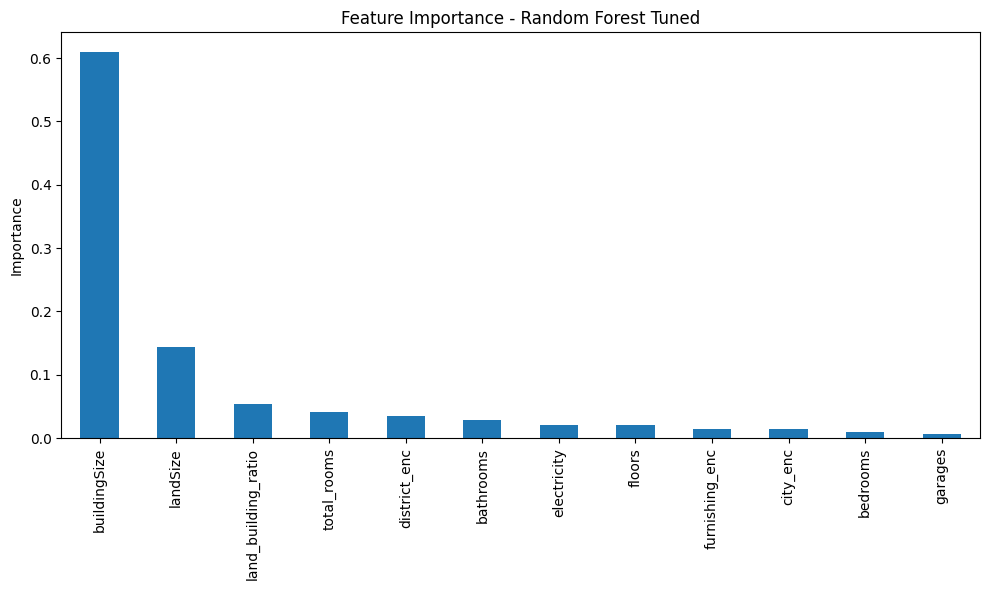

In [34]:
# Plot feature importance
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance - Random Forest Tuned')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [31]:
# 12. Simpan Model dan Encoder untuk Produksi
# =====================================================
import joblib

joblib.dump(best_rf, "model_rumah_jogja_rf_tuned.pkl")
joblib.dump(lr, "model_rumah_jogja_lr.pkl")
joblib.dump(dt, "model_rumah_jogja_dt.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_district, "encoder_district.pkl")
joblib.dump(le_city, "encoder_city.pkl")
joblib.dump(le_furnishing, "encoder_furnishing.pkl")

['encoder_furnishing.pkl']

In [33]:
# Simpan juga daftar fitur (urutan penting saat prediksi)
with open("features.txt", "w") as f:
    for feat in features:
        f.write(feat + "\n")

print("\nModel dan encoder berhasil disimpan.")


Model dan encoder berhasil disimpan.


In [32]:
# Contoh Prediksi dengan Model Terbaik (Random Forest)
# =====================================================
print("\n=== Contoh Prediksi ===")
# Ambil satu sampel dari data test
sample = X_test.iloc[0:1]
sample_actual = y_test.iloc[0]

# Prediksi
sample_pred = best_rf.predict(sample)[0]

print(f"Harga aktual: Rp{sample_actual:,.0f}")
print(f"Harga prediksi: Rp{sample_pred:,.0f}")
print(f"Selisih: Rp{abs(sample_actual - sample_pred):,.0f}")
print(f"Persentase error: {abs(sample_actual - sample_pred) / sample_actual * 100:.2f}%")


=== Contoh Prediksi ===
Harga aktual: Rp3,200,000,000
Harga prediksi: Rp2,715,243,333
Selisih: Rp484,756,667
Persentase error: 15.15%
